# Force Mortality (Stata → Python)

This notebook reproduces Casper Worm Hansen's Stata workflow using Python:

- Scatter plots: mortality_rate vs age_id for Danish males (1910, 1950, 2010)
- Nonlinear Gompertz-Makeham fit: m = a + b * exp(c * age)
- Log-linear Gompertz fit (Makeham=0): ln(m) = intercept + slope * age
- Survival curve implied by Makeham=0 Gompertz

In [1]:
import sys
from pathlib import Path

# Make sure we can import from ../src when running from notebooks/
cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    project_root = cwd
elif (cwd.parent / "src").exists():
    project_root = cwd.parent
else:
    raise RuntimeError("Could not find project root (folder containing src/)")

sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.force_mortality import (
    XTICKS,
    load_stata,
    subset_country_sex_year,
    plot_scatter_mortality_age,
    plot_joint_scatter_years,
    fit_gompertz_makeham_nl,
    add_nl_prediction_column,
    plot_line_vs_scatter,
    add_log_mortality,
    fit_loglinear_gompertz,
    add_loglinear_predictions_for_years,
    add_survival_curve_column,
)

plt.rcParams["figure.figsize"] = (8, 4.5)

## Code (load data)

In [3]:
# ADJUST PATH TO YOUR DATASET
DATA_PATH = r"C:\Users\Anton\Demography\translation_of_STATA_code\data\processed\HMD_5yr_mort_rates.dta"

df = load_stata(DATA_PATH)
df.head()

,sex_nr,year,age_HMD,mortality_rate,isocode,age_id
0,1,1921,0,0.068444,AUS,0.0
1,2,1921,0,0.059987,AUS,0.0
2,3,1921,0,0.076533,AUS,0.0
3,1,1922,0,0.054918,AUS,0.0
4,2,1922,0,0.045943,AUS,0.0


## Scatter plots: DNK males, different years

Equivalent to Stata:
`sc mortality_rate age_id if isocode=="DNK" & year==... & sex_nr==3`


## Joint scatter

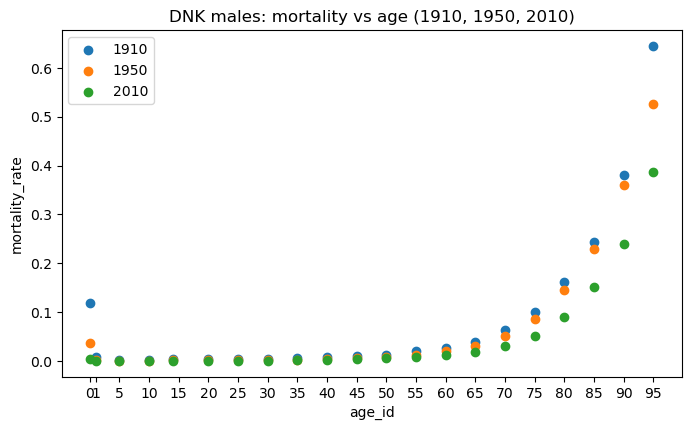

In [7]:
isocode = "DNK"
sex_nr = 3

plot_joint_scatter_years(
    df,
    isocode=isocode,
    sex_nr=sex_nr,
    years=[1910, 1950, 2010],
    title="DNK males: mortality vs age (1910, 1950, 2010)",
)
plt.show()


## Nonlinear Gompertz law with Makeham constant

Stata:
`nl (mortality_rate = {a} + {b} * exp({c} * age_id)) if ..., initial(a 0.005 b 0.001 c 0.1)`


## NL fit for 1950

In [10]:
d1950 = subset_country_sex_year(df, isocode, sex_nr, 1950)


nl_1950 = fit_gompertz_makeham_nl(d1950, initial=(0.005, 0.001, 0.1), nonnegative=True)
nl_1950

GompertzMakehamParams(a=0.0011149871078826009, b=0.00011927328230336612, c=0.08851135621820316)

## NL predictions + plot for 1950

In [ ]:
d1950_nl = add_nl_prediction_column(d1950, nl_1950, colname="NL_predict_mort")

plot_line_vs_scatter(
    d1950_nl,
    x_col="age_id",
    y_line_col="NL_predict_mort",
    y_scatter_col="mortality_rate",
    title="DNK males 1950: Gompertz-Makeham NL fit vs observed",
)
plt.show()


## Log-linear Gompertz with Makeham = 0

Stata:
- `gen lnmortality_rate=ln(mortality_rate)`
- `reg lnmortality_rate age_id if ...`
- Predict: `ln_predict_mort = intercept + slope*age_id`
- `predict_mort=exp(ln_predict_mort)`


## Create log mortality + fit regressions

In [ ]:
df_log = add_log_mortality(df)

d1950_ll = subset_country_sex_year(df_log, isocode, sex_nr, 1950)
d2010_ll = subset_country_sex_year(df_log, isocode, sex_nr, 2010)

ll_1950_params, ll_1950_model = fit_loglinear_gompertz(d1950_ll)
ll_2010_params, ll_2010_model = fit_loglinear_gompertz(d2010_ll)

ll_1950_params, ll_2010_params

c:\Users\Anton\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(LogLinearGompertzParams(intercept=-7.429808944194669, slope=0.06288617557006163),
 LogLinearGompertzParams(intercept=-9.07196307601053, slope=0.0804392038819235))

## Print regression outputs

In [12]:
print(ll_1950_model.summary())
print("\n" + "="*80 + "\n")
print(ll_2010_model.summary())

                            OLS Regression Results                            
Dep. Variable:       lnmortality_rate   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     56.03
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           4.43e-07
Time:                        20:50:05   Log-Likelihood:                -31.686
No. Observations:                  21   AIC:                             67.37
Df Residuals:                      19   BIC:                             69.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.4298      0.455    -16.313      0.0

## Predictions + plots 1950 and 2010

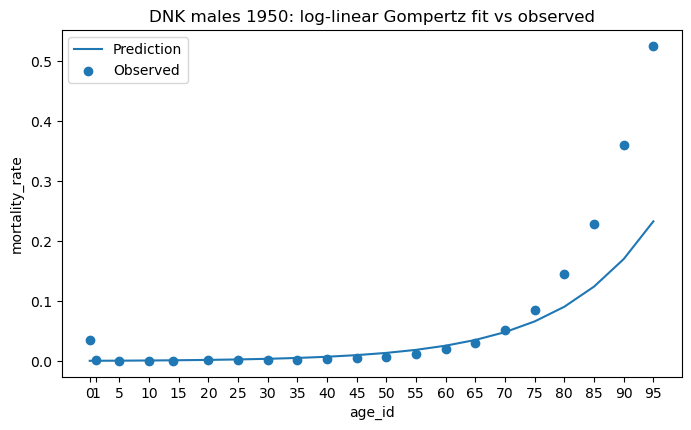

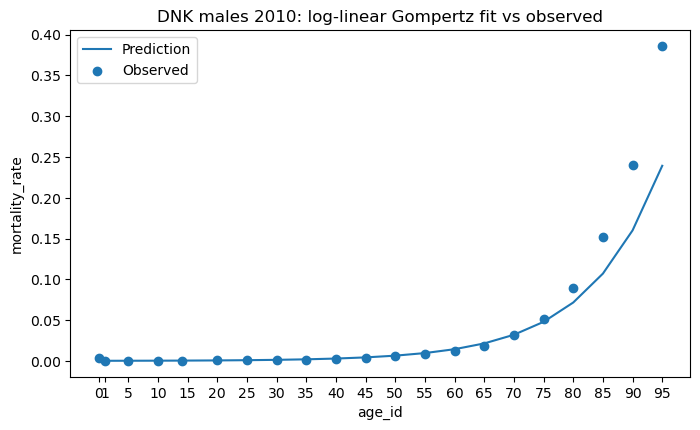

In [13]:
df_pred = add_loglinear_predictions_for_years(
    df_log,
    params_by_year={1950: ll_1950_params, 2010: ll_2010_params},
    isocode=isocode,
    sex_nr=sex_nr,
)

p1950 = subset_country_sex_year(df_pred, isocode, sex_nr, 1950)
p2010 = subset_country_sex_year(df_pred, isocode, sex_nr, 2010)

plot_line_vs_scatter(
    p1950,
    x_col="age_id",
    y_line_col="predict_mort",
    y_scatter_col="mortality_rate",
    title="DNK males 1950: log-linear Gompertz fit vs observed",
)
plt.show()

plot_line_vs_scatter(
    p2010,
    x_col="age_id",
    y_line_col="predict_mort",
    y_scatter_col="mortality_rate",
    title="DNK males 2010: log-linear Gompertz fit vs observed",
)
plt.show()


## Survival curve with Makeham = 0

Stata:
- `b_1950=exp(b_ln_1950)`
- `l_curve=1000*exp( (-b_1950/c_ln_1950)*(exp(c_ln_1950*age_id) - 1))`


## Code (survival curve plot for 1950)

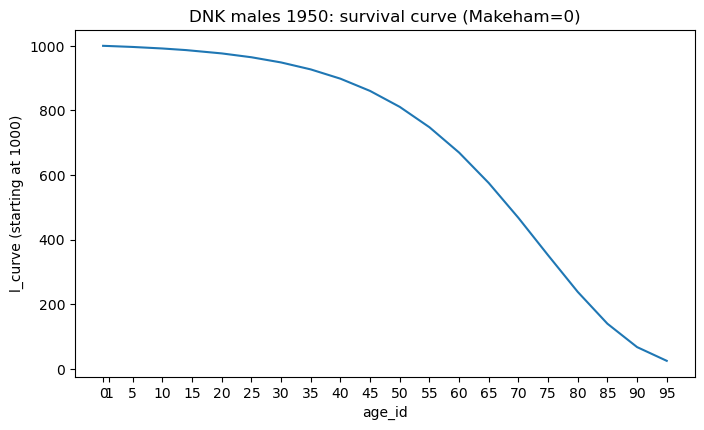

In [14]:
surv1950 = add_survival_curve_column(p1950, ll_1950_params, colname="l_curve", start_population=1000.0)

plt.figure()
plt.plot(surv1950["age_id"], surv1950["l_curve"])
plt.xticks(XTICKS)
plt.xlabel("age_id")
plt.ylabel("l_curve (starting at 1000)")
plt.title("DNK males 1950: survival curve (Makeham=0)")
plt.show()
